# Step 10: Live demo

Shows that the project collects earthquake data from USGS while it is being
worked on, and replays the newly collected events on a map in time order.

**How to run it for the video**

1. In a terminal: `python scripts/usgs_fetch.py` (asks USGS for everything new since the last run).
2. Run this notebook from top to bottom.

Live data = rows of `data/raw/quakes_m45_raw.csv` that our script first saw
**and** that occurred after `LIVE_START` (set in `scripts/config.py`). The
check on the event time removes old earthquakes that USGS added late or moved
to a new id.

The Isolation Forest saved by Step 6 then scores the grid cells that had new
events and the map marks the cells it flags as unusual.

Outputs: `figures/step10_live_replay.html` (animated map), `figures/step10_live_map.png`
(still image for the slides), `results/step10_*.csv`.

In [1]:
import sys
sys.path.append("../scripts")
from config import *

import json
import math
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+notebook_connected"

BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, MUTED, GRID, SURFACE, LAND = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb", "#eeede9"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True, "grid.color": GRID,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left", "font.size": 10,
})
for folder in (FIGURES_DIR, RESULTS_DIR):
    folder.mkdir(parents=True, exist_ok=True)

RUN_FETCH = False   # True = this notebook runs usgs_fetch.py itself before loading the data

## 1. (Optional) fetch new data from USGS

In [2]:
if RUN_FETCH:
    out = subprocess.run([sys.executable, str(ROOT / "scripts" / "usgs_fetch.py")],
                         capture_output=True, text=True, encoding="utf-8")
    print(out.stdout or out.stderr)
else:
    print("RUN_FETCH is False: using the raw file as it is. Run `python scripts/usgs_fetch.py` first for new data.")

RUN_FETCH is False: using the raw file as it is. Run `python scripts/usgs_fetch.py` first for new data.


## 2. Pick the live events out of the raw file

In [3]:
raw = pd.read_csv(RAW_FILE, dtype={"id": str}, encoding="utf-8")
for col in ("time", "updated", "first_seen_at", "last_fetched_at"):
    raw[col] = pd.to_datetime(raw[col], utc=True, format="ISO8601")

start = pd.Timestamp(LIVE_START)
usable = (raw["status"] != "deleted") & (raw["type"] == "earthquake") & (raw["mag"] >= MIN_MAG)
seen_after = usable & (raw["first_seen_at"] > start)
live = raw[seen_after & (raw["time"] > start)].sort_values("time").reset_index(drop=True)
late = raw[seen_after & (raw["time"] <= start)]

days = (live["time"].max() - start).total_seconds() / 86400 if len(live) else 0.0
top = live.loc[live["mag"].idxmax()] if len(live) else None

summary = pd.DataFrame([
    {"item": "raw rows", "value": len(raw)},
    {"item": "live start (UTC)", "value": str(start)},
    {"item": "last fetch (UTC)", "value": str(raw["last_fetched_at"].max())},
    {"item": "rows first seen after live start", "value": int(seen_after.sum())},
    {"item": "of these: older events added late (excluded)", "value": len(late)},
    {"item": "live events (M4.5+)", "value": len(live)},
    {"item": "first live event (UTC)", "value": str(live["time"].min()) if len(live) else ""},
    {"item": "last live event (UTC)", "value": str(live["time"].max()) if len(live) else ""},
    {"item": "days covered", "value": round(days, 2)},
    {"item": "live events per day", "value": round(len(live) / days, 1) if days else ""},
    {"item": "largest live event", "value": f"M{top['mag']} {top['place']} ({top['time']:%Y-%m-%d %H:%M} UTC)" if top is not None else ""},
    {"item": "live events with M >= MAJOR_MAG", "value": int((live["mag"] >= MAJOR_MAG).sum())},
])
summary.to_csv(RESULTS_DIR / "step10_live_summary.csv", index=False)
assert len(live) > 0, "no live events yet: run usgs_fetch.py first"
summary

,item,value
0,raw rows,187588
1,live start (UTC),2026-10-08 10:00:00+00:00
2,last fetch (UTC),2026-10-10 12:36:03.972000+00:00
3,rows first seen after live start,91
4,of these: older events added late (excluded),22
5,live events (M4.5+),69
6,first live event (UTC),2026-10-08 10:07:28.642000+00:00
7,last live event (UTC),2026-10-10 10:35:11.922000+00:00
8,days covered,2.02
9,live events per day,34.1


### When did each event reach us?

We run the fetch script when we need the data, not continuously. Every run
stamps the rows it adds with the same `first_seen_at`, so one row below = one run.

In [4]:
runs = (raw[seen_after].assign(is_live=raw["time"] > start)
        .groupby("first_seen_at")
        .agg(live_events=("is_live", "sum"), older_events_added_late=("is_live", lambda s: int((~s).sum())),
             earliest_event=("time", "min"), latest_event=("time", "max"))
        .reset_index().rename(columns={"first_seen_at": "fetch_run_utc"}))
runs.to_csv(RESULTS_DIR / "step10_fetch_runs.csv", index=False)
runs

,fetch_run_utc,live_events,older_events_added_late,earliest_event,latest_event
0,2026-10-08 10:02:43+00:00,0,1,2026-10-08 09:00:07.768000+00:00,2026-10-08 09:00:07.768000+00:00
1,2026-10-10 12:36:03.972000+00:00,69,21,2026-07-20 22:27:49.636000+00:00,2026-10-10 10:35:11.922000+00:00


In [5]:
latest_run = live["first_seen_at"].max()
newest = live[live["first_seen_at"] == latest_run].sort_values("time", ascending=False)
print(f"The last run that brought new events ({latest_run:%Y-%m-%d %H:%M} UTC) added {len(newest)} live events. Newest first:")
newest[["time", "mag", "magType", "depth", "place"]].head(15)

The last run that brought new events (2026-10-10 12:36 UTC) added 69 live events. Newest first:


,time,mag,magType,depth,place
68,2026-10-10 10:35:11.922000+00:00,4.8,mb,10.000,"4 km NE of Río Grande, Panama"
67,2026-10-10 09:42:58.899000+00:00,4.6,mb,30.387,"31 km SE of Vanimo, Papua New Guinea"
66,2026-10-10 08:38:50.674000+00:00,4.5,mb,79.424,"61 km N of Hihifo, Tonga"
65,2026-10-10 07:13:30.583000+00:00,4.6,mb,10.000,"6 km SSE of Llano de Piedra, Panama"
64,2026-10-10 06:47:49.431000+00:00,4.5,mb,10.000,"10 km SE of Pedasí, Panama"
63,2026-10-10 06:30:03.521000+00:00,4.9,mb,10.000,"26 km SSE of Pedasí, Panama"
62,2026-10-10 06:27:09.602000+00:00,4.7,mb,10.000,"26 km S of Pedasí, Panama"
61,2026-10-10 06:18:55.288000+00:00,4.9,mb,10.000,"10 km SSW of Cañas, Panama"
60,2026-10-10 06:16:32.545000+00:00,4.5,mb,10.000,"25 km SSE of Pedasí, Panama"
59,2026-10-10 05:45:59.396000+00:00,4.5,mb,115.143,"6 km WSW of Filadelfia, Colombia"


## 3. Score the new activity with the Isolation Forest of Step 6

The model looks at one **grid cell x week** at a time. The features are built
exactly as in `05_anomaly.ipynb` (the recipe is stored next to the model in
`models/isoforest_features.json`): number of events, how many times the cell's
normal weekly rate that is (log10), mean depth, how spread out the events are
(km) and mean magnitude. The largest magnitude is **not** a feature.

All usable events of a week are used, not only the live ones, because the week
that contains `LIVE_START` began before it. The current week is still running,
so its score can change with the next fetch.

In [6]:
EARTH_KM = 6371.0088

def cell_week_features(events, spec):
    # one row per grid cell x Monday-start week, with the features the model was trained on
    d = events.copy()
    d["cell_id"] = [cell_id(a, o) for a, o in zip(d["latitude"], d["longitude"])]
    d["week"] = d["time"].dt.tz_localize(None).dt.to_period("W-SUN").dt.start_time
    g = d.groupby(["cell_id", "week"])
    lat0, lon0 = g["latitude"].transform("mean"), g["longitude"].transform("mean")
    la1, lo1, la2, lo2 = map(np.radians, (d["latitude"], d["longitude"], lat0, lon0))
    a = np.sin((la2 - la1) / 2) ** 2 + np.cos(la1) * np.cos(la2) * np.sin((lo2 - lo1) / 2) ** 2
    d["km_to_centre"] = 2 * EARTH_KM * np.arcsin(np.sqrt(a))
    cw = g.agg(n_events=("id", "size"), max_mag=("mag", "max"), mean_mag=("mag", "mean"),
               mean_depth=("depth", "mean"), spread_km=("km_to_centre", "mean"),
               place=("place", "last")).reset_index()
    normal = cw["cell_id"].map(spec["baseline_weekly_rate"]).fillna(spec["baseline_floor"])
    cw["rate_ratio"] = cw["n_events"] / normal
    cw["log_rate_ratio"] = np.log10(cw["rate_ratio"])
    return cw

model_file, spec_file = MODELS_DIR / "isoforest.joblib", MODELS_DIR / "isoforest_features.json"
HAVE_MODEL = model_file.exists() and spec_file.exists()
if HAVE_MODEL:
    import joblib
    import warnings
    from sklearn.exceptions import InconsistentVersionWarning
    # the model may have been saved with another scikit-learn patch version;
    # the check in the next cell confirms the scores are identical
    warnings.simplefilter("ignore", InconsistentVersionWarning)
    model = joblib.load(model_file)
    spec = json.loads(spec_file.read_text(encoding="utf-8"))
    print("model:", type(model).__name__, "| trained on", spec["trained_on"])
    print("features:", spec["features"])
    print("flag when score >=", spec["cut_score"], f"(contamination {spec['contamination']})")
else:
    print("Step 6 model not found in models/: the maps below are drawn without anomaly labels.")

model: IsolationForest | trained on cell-weeks up to 2019-12-31
features: ['n_events', 'log_rate_ratio', 'mean_depth', 'spread_km', 'mean_mag']
flag when score >= 0.683454 (contamination 0.002)


### Check: do we get the same scores as Step 6?

Before trusting the live scores, the same code is run on past weeks and
compared with the scores Step 6 saved in `results/step6_cell_week_scores.csv`.

In [7]:
step6_file = RESULTS_DIR / "step6_cell_week_scores.csv"
if HAVE_MODEL and CLEAN_FILE.exists() and step6_file.exists():
    past = pd.read_csv(CLEAN_FILE, dtype={"id": str})
    past["time"] = pd.to_datetime(past["time"], utc=True, format="ISO8601")
    past = past[past["time"] >= pd.Timestamp("2025-01-06", tz="UTC")].assign(place="")
    ours = cell_week_features(past, spec)
    ours["score"] = -model.score_samples(ours[spec["features"]])
    theirs = pd.read_csv(step6_file, parse_dates=["week"])
    both = ours.merge(theirs, on=["cell_id", "week"], suffixes=("", "_step6"))
    same = np.isclose(both["score"], both["score_step6"], atol=1e-6)
    print(f"cell-weeks compared (2025 onward): {len(both):,} | same score: {int(same.sum()):,} | different: {int((~same).sum()):,}")
    assert len(both) > 0 and same.all(), "features are not built the same way as in Step 6"
else:
    print("skipped: needs the model, quakes_clean.csv and results/step6_cell_week_scores.csv")

cell-weeks compared (2025 onward): 6,442 | same score: 6,442 | different: 0


In [8]:
scored = pd.DataFrame()
if HAVE_MODEL:
    first_week = start.tz_localize(None).to_period("W-SUN").start_time
    recent = raw[usable & (raw["time"] >= pd.Timestamp(first_week, tz="UTC"))]
    scored = cell_week_features(recent, spec)
    live_count = (live.assign(cell_id=[cell_id(a, o) for a, o in zip(live["latitude"], live["longitude"])],
                              week=live["time"].dt.tz_localize(None).dt.to_period("W-SUN").dt.start_time)
                  .groupby(["cell_id", "week"]).size().rename("live_events"))
    scored = scored.join(live_count, on=["cell_id", "week"])
    scored = scored[scored["live_events"].notna()].astype({"live_events": int})   # only cells with new events
    scored["score"] = -model.score_samples(scored[spec["features"]])
    scored["flagged"] = (scored["score"] >= spec["cut_score"]).astype(int)
    scored = scored.sort_values("score", ascending=False).reset_index(drop=True)
    out_cols = ["cell_id", "week", "n_events", "live_events", "rate_ratio", "mean_depth", "spread_km",
                "mean_mag", "max_mag", "score", "flagged", "place"]
    rounding = {"rate_ratio": 1, "mean_depth": 1, "spread_km": 1, "mean_mag": 2, "score": 4}
    scored[out_cols].round(rounding).to_csv(RESULTS_DIR / "step10_anomaly_scores.csv", index=False)

    print(f"cell-weeks with live events: {len(scored)} | flagged as unusual: {int(scored['flagged'].sum())}")
    facts_file = RESULTS_DIR / "step6_facts.csv"
    if facts_file.exists():
        f6 = pd.read_csv(facts_file).set_index("item")["value"]
        print(f"How far to trust a flag (Step 6, on years the model never saw): precision {f6['test precision B']}, "
              f"recall {f6['test recall B']}, random guessing {f6['test random precision']}")
    display(scored[out_cols].head(12).round(rounding))
flagged_cells = sorted(scored.loc[scored["flagged"] == 1, "cell_id"].unique()) if len(scored) else []

def cell_outline(cid):
    # corner coordinates (closed ring) of a grid cell such as '5_-85'
    la, lo = (int(v) for v in cid.split("_"))
    return [lo, lo + GRID_DEG, lo + GRID_DEG, lo, lo], [la, la, la + GRID_DEG, la + GRID_DEG, la]

cell-weeks with live events: 24 | flagged as unusual: 0
How far to trust a flag (Step 6, on years the model never saw): precision 0.424, recall 0.259, random guessing 0.004


,cell_id,week,n_events,live_events,rate_ratio,mean_depth,spread_km,mean_mag,max_mag,score,flagged,place
0,5_-85,2026-10-05,35,35,79.0,10.5,49.1,5.05,7.7,0.6768,0,"4 km NE of Río Grande, Panama"
1,-25_175,2026-10-05,4,1,7.3,513.4,23.2,4.68,5.0,0.5958,0,south of the Fiji Islands
2,-20_-180,2026-10-05,3,3,1.3,600.6,65.8,4.80,5.1,0.5920,0,"97 km E of Levuka, Fiji"
3,5_-80,2026-10-05,6,6,33.7,27.5,147.6,4.60,4.9,0.5559,0,"10 km SE of Pedasí, Panama"
4,-20_165,2026-10-05,3,1,1.4,18.3,49.3,5.43,6.3,0.5112,0,"99 km NE of Norsup, Vanuatu"
5,0_125,2026-10-05,4,3,1.1,27.8,138.6,5.03,5.2,0.4865,0,"141 km E of Bitung, Indonesia"
6,-65_150,2026-10-05,1,1,11.0,10.0,0.0,5.90,5.9,0.4817,0,west of Macquarie Island
7,-10_150,2026-10-05,2,1,0.6,96.5,121.1,4.75,4.8,0.4698,0,"121 km S of Kokopo, Papua New Guinea"
8,-5_140,2026-10-05,2,1,3.0,65.9,157.1,4.60,4.6,0.4687,0,"31 km SE of Vanimo, Papua New Guinea"
9,50_160,2026-10-05,3,2,5.9,17.8,137.6,4.77,4.8,0.4636,0,"191 km SE of Petropavlovsk-Kamchatsky, Russia"


saved C:\coding\University HW\Earthquake-project\figures\step10_anomaly_scores.png


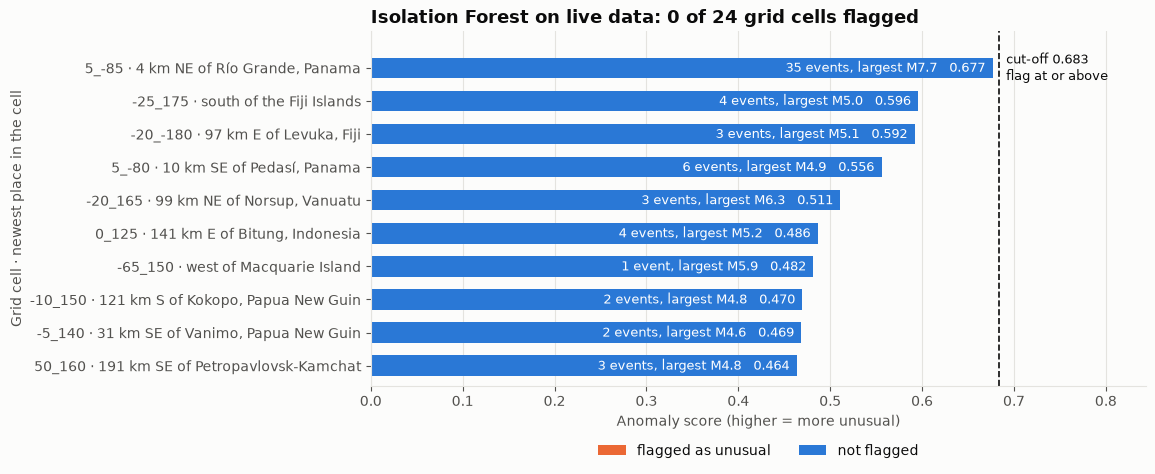

In [9]:
if HAVE_MODEL and len(scored):
    top10 = scored.head(10).iloc[::-1]
    cut = spec["cut_score"]
    labels = [f"{r.cell_id} · {r.place[:34]}" for r in top10.itertuples()]
    fig, ax = plt.subplots(figsize=(10, 4.6))
    bars = ax.barh(labels, top10["score"], color=[ORANGE if f else BLUE for f in top10["flagged"]], height=0.62)
    for b, r in zip(bars, top10.itertuples()):
        ax.text(r.score - 0.008, b.get_y() + b.get_height() / 2,
                f"{r.n_events} event{'s' if r.n_events > 1 else ''}, largest M{r.max_mag}   {r.score:.3f}",
                va="center", ha="right", fontsize=9, color="white")
    ax.axvline(cut, color=INK, lw=1.2, ls="--")
    ax.text(cut + 0.008, len(top10) - 1, f"cut-off {cut:.3f}\nflag at or above", color=INK, fontsize=9, va="center")
    ax.set_xlim(0, max(cut, top10["score"].max()) + 0.16)
    ax.set_ylim(-0.6, len(top10) + 0.1)
    ax.set_xlabel("Anomaly score (higher = more unusual)")
    ax.set_ylabel("Grid cell · newest place in the cell")
    best = scored.iloc[0]
    n_flag = int(scored["flagged"].sum())
    ax.set_title(f"Isolation Forest on live data: {n_flag} of {len(scored)} grid cells flagged")
    ax.bar([0], [0], color=ORANGE, label="flagged as unusual")
    ax.bar([0], [0], color=BLUE, label="not flagged")
    ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=2)
    ax.grid(axis="y", visible=False)
    fig.savefig(FIGURES_DIR / "step10_anomaly_scores.png", dpi=FIG_DPI, bbox_inches="tight")
    print("saved", FIGURES_DIR / "step10_anomaly_scores.png")
    plt.show()

## 4. Replay on a map

Events appear in the order they happened. Orange = the events that just
arrived in this step, blue = the ones already shown. Marker area grows with
magnitude. A dark outline marks a grid cell the Isolation Forest flags as
unusual. Press **Play**, or drag the slider.

In [10]:
MAX_FRAMES = 150
per_frame = max(1, math.ceil(len(live) / MAX_FRAMES))

def marker_size(mag):
    return 6 + (np.asarray(mag) - MIN_MAG) * 7

def hover(d):
    return [f"M{m} · {p}<br>{t:%Y-%m-%d %H:%M} UTC · depth {z:.0f} km"
            for m, p, t, z in zip(d["mag"], d["place"], d["time"], d["depth"])]

def trace(d, name, color, opacity):
    return go.Scattergeo(lon=d["longitude"], lat=d["latitude"], text=hover(d), hoverinfo="text", name=name,
                         marker={"size": marker_size(d["mag"]), "color": color, "opacity": opacity,
                                 "line": {"width": 1, "color": SURFACE}})

frames, steps = [], []
for lo in range(0, len(live), per_frame):
    hi = min(lo + per_frame, len(live))
    when = live["time"].iloc[hi - 1]
    name = f"{when:%d %b %H:%M}"
    frames.append(go.Frame(
        name=name,
        data=[trace(live.iloc[:lo], "already shown", BLUE, 0.55), trace(live.iloc[lo:hi], "just arrived", ORANGE, 0.95)],
        traces=[0, 1],
        layout={"annotations": [{"text": f"<b>{hi}</b> of {len(live)} events · up to {when:%d %b %Y %H:%M} UTC",
                                 "x": 0.0, "y": 1.0, "xref": "paper", "yref": "paper", "xanchor": "left",
                                 "yanchor": "bottom", "showarrow": False, "font": {"size": 14, "color": INK}}]}))
    steps.append({"label": name, "method": "animate",
                  "args": [[name], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}}]})

fig = go.Figure(data=frames[0].data, frames=frames)
ring_lon, ring_lat = [], []
for cid in flagged_cells:                      # one line trace, rings separated by None
    lo_, la_ = cell_outline(cid)
    ring_lon += lo_ + [None]; ring_lat += la_ + [None]
if flagged_cells:
    fig.add_trace(go.Scattergeo(lon=ring_lon, lat=ring_lat, mode="lines", hoverinfo="skip",
                                line={"width": 2, "color": INK},
                                name=f"flagged by Isolation Forest ({len(flagged_cells)} grid cell{'s' if len(flagged_cells) > 1 else ''})"))
fig.update_layout(
    title={"text": f"Live earthquakes replayed in time order<br><sup>M{MIN_MAG}+ worldwide, collected since {start:%d %b %Y %H:%M} UTC</sup>",
           "x": 0.01, "font": {"size": 17, "color": INK}},
    showlegend=True,
    annotations=frames[0].layout.annotations,
    paper_bgcolor=SURFACE, font={"color": MUTED}, height=660, margin={"l": 10, "r": 10, "t": 100, "b": 20},
    legend={"orientation": "h", "x": 1.0, "xanchor": "right", "y": 1.0, "yanchor": "bottom"},
    geo={"projection": {"type": "natural earth"}, "showland": True, "landcolor": LAND, "showocean": True,
         "oceancolor": SURFACE, "showcountries": True, "countrycolor": "#d6d5cf", "coastlinecolor": "#b9b8b1",
         "showframe": False, "bgcolor": SURFACE, "lataxis": {"range": [-75, 85]}},
    updatemenus=[{"type": "buttons", "direction": "left", "x": 0.0, "y": 0.0, "xanchor": "left", "yanchor": "top",
                  "buttons": [
                      {"label": "Play", "method": "animate",
                       "args": [None, {"frame": {"duration": 250, "redraw": True}, "fromcurrent": True, "transition": {"duration": 0}}]},
                      {"label": "Pause", "method": "animate",
                       "args": [[None], {"mode": "immediate", "frame": {"duration": 0, "redraw": False}}]}]}],
    sliders=[{"steps": steps, "x": 0.0, "len": 1.0, "y": -0.09, "yanchor": "top",
              "currentvalue": {"prefix": "Up to (UTC): ", "xanchor": "right", "font": {"color": INK}}}],
)
fig.write_html(FIGURES_DIR / "step10_live_replay.html", include_plotlyjs=True, auto_play=False)
print(f"{len(frames)} steps, {per_frame} event(s) per step -> saved", FIGURES_DIR / "step10_live_replay.html")
fig.show()

69 steps, 1 event(s) per step -> saved C:\coding\University HW\Earthquake-project\figures\step10_live_replay.html


## 5. Still image for the slides

The grey background is every earthquake in the cleaned history file, so the
plate boundaries are visible without a base map.

saved C:\coding\University HW\Earthquake-project\figures\step10_live_map.png


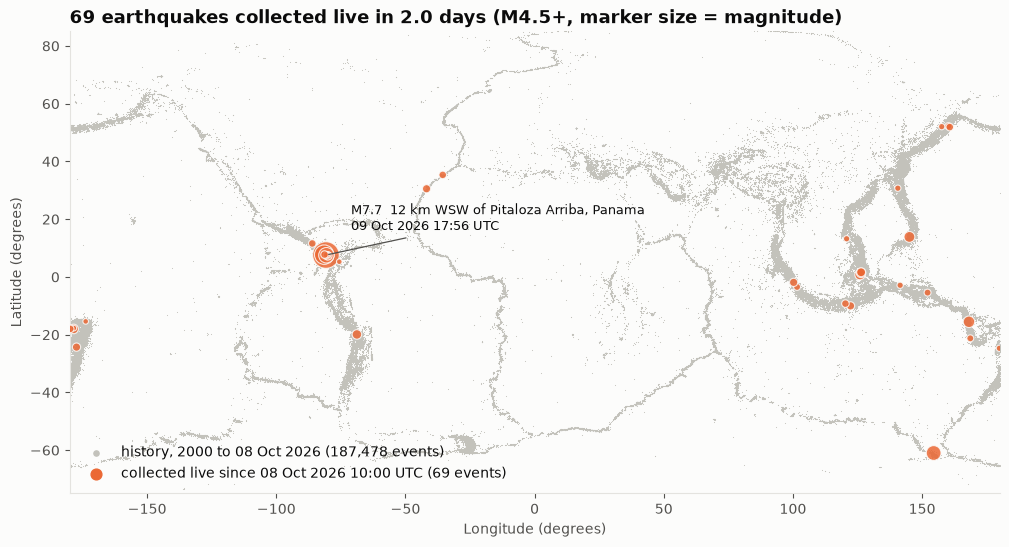

In [11]:
history = pd.read_csv(CLEAN_FILE, parse_dates=["time"]) if CLEAN_FILE.exists() else raw[usable]
history = history[history["time"] < start]

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(history["longitude"], history["latitude"], s=0.6, color="#c3c2bb", linewidths=0, rasterized=True)
ax.scatter(live["longitude"], live["latitude"], s=marker_size(live["mag"]) ** 2 / 2.2, color=ORANGE, alpha=0.85,
           edgecolors=SURFACE, linewidths=0.8, zorder=3)
ax.annotate(f"M{top['mag']}  {top['place']}\n{top['time']:%d %b %Y %H:%M} UTC",
            xy=(top["longitude"], top["latitude"]), xytext=(18, 18), textcoords="offset points",
            color=INK, fontsize=9.5, arrowprops={"arrowstyle": "-", "color": MUTED, "lw": 0.9}, zorder=4)
for cid in flagged_cells:
    lo_, la_ = cell_outline(cid)
    ax.plot(lo_, la_, color=INK, lw=1.6, zorder=5)
if flagged_cells:
    ax.plot([], [], color=INK, lw=1.6, label=f"grid cell flagged by Isolation Forest ({len(flagged_cells)})")
ax.scatter([], [], s=14, color="#c3c2bb", label=f"history, {history['time'].min():%Y} to {start:%d %b %Y} ({len(history):,} events)")
ax.scatter([], [], s=60, color=ORANGE, label=f"collected live since {start:%d %b %Y %H:%M} UTC ({len(live)} events)")
ax.legend(frameon=False, loc="lower left")
ax.set_xlim(-180, 180); ax.set_ylim(-75, 85)
ax.set_xlabel("Longitude (degrees)"); ax.set_ylabel("Latitude (degrees)")
ax.set_title(f"{len(live)} earthquakes collected live in {days:.1f} days (M{MIN_MAG}+, marker size = magnitude)")
ax.grid(False)
fig.savefig(FIGURES_DIR / "step10_live_map.png", dpi=FIG_DPI, bbox_inches="tight")
if HAVE_MODEL:
    extra = pd.DataFrame([
        {"item": "cell-weeks with live events scored", "value": len(scored)},
        {"item": "cell-weeks flagged by Isolation Forest", "value": int(scored["flagged"].sum())},
        {"item": "flagged grid cells", "value": ", ".join(flagged_cells)},
        {"item": "model cut score", "value": spec["cut_score"]},
    ])
    pd.concat([summary, extra]).to_csv(RESULTS_DIR / "step10_live_summary.csv", index=False)
print("saved", FIGURES_DIR / "step10_live_map.png")
plt.show()